Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 10608 entries, 02/01/1981 to 27/01/2023
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10608 non-null  float64
 1   High       10608 non-null  float64
 2   Low        10608 non-null  float64
 3   Close      10608 non-null  float64
 4   Adj Close  10608 non-null  float64
 5   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 580.1+ KB
None

Missing Values:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Date Range:
01/02/1982 to 31/12/2021


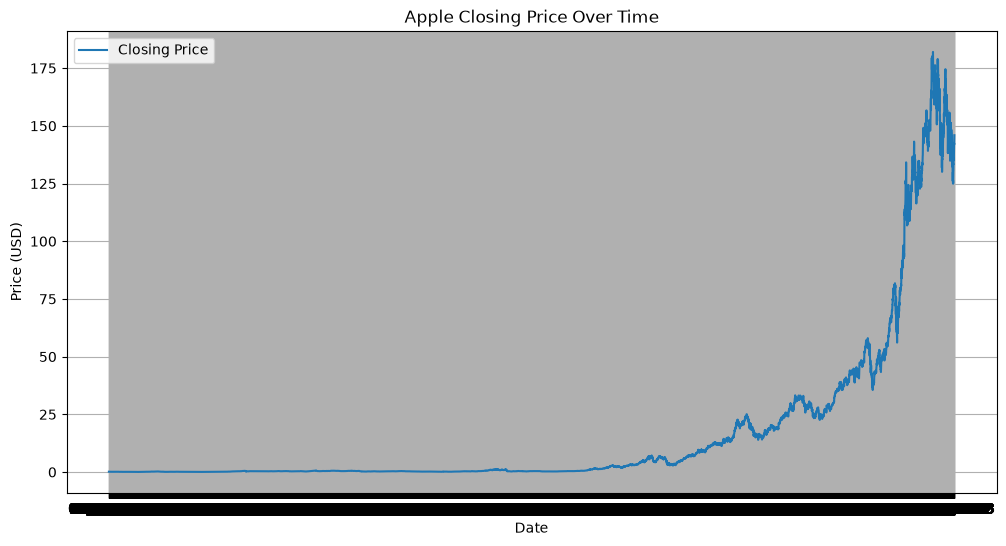

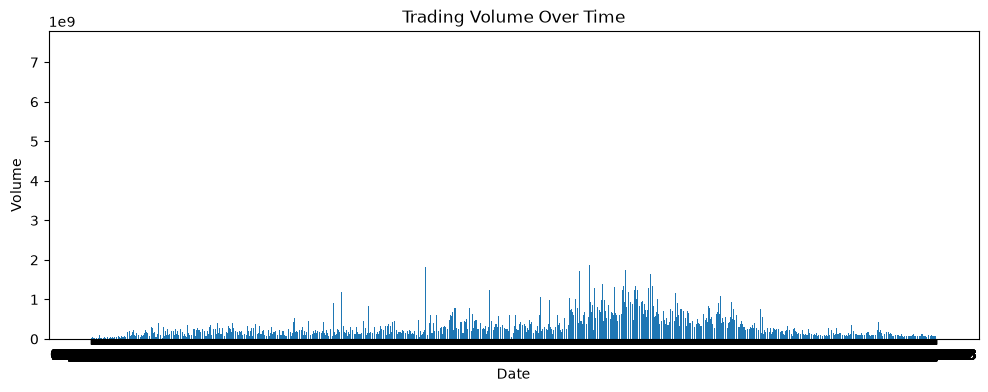

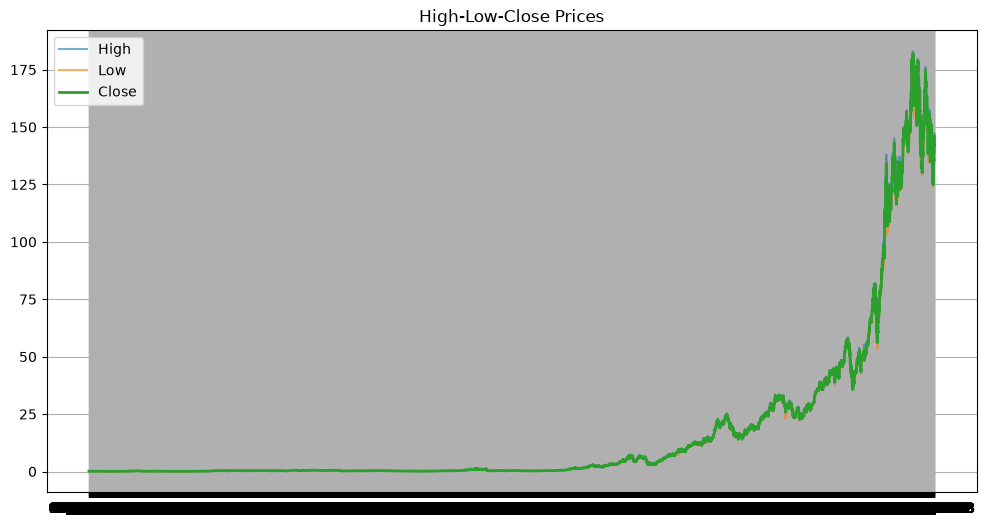


Summary Statistics (Close Price)
Mean: 16.69736201451735
Median: 0.487701
Standard Deviation: 35.47223956417654


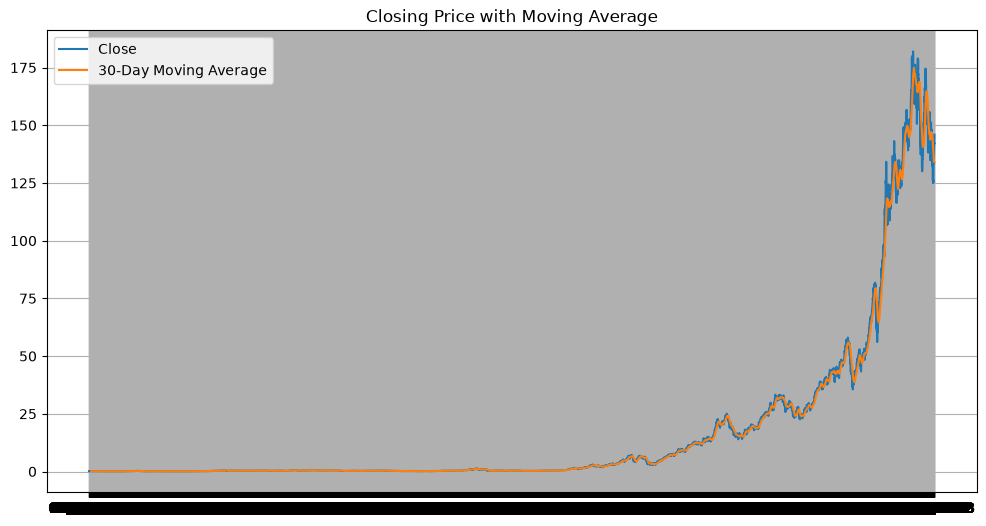

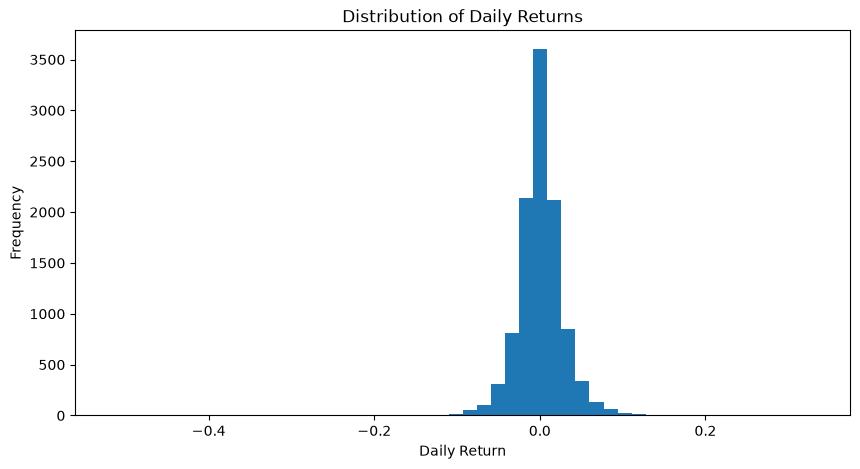


Shapiro-Wilk Test for Normality:
Statistic: 0.9190583946174027
p-value: 1.7898289463728573e-59


c:\Users\GUE\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10607.
  res = hypotest_fun_out(*samples, **kwds)


AttributeError: 'Index' object has no attribute 'year'

In [ ]:
# ============================================================
# MINI-PROJECT: ADVANCED STATISTICAL ANALYSIS OF AAPL STOCK
# NumPy + Pandas + Matplotlib + SciPy
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT DES LIBRAIRIES
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------
# 2. DATA LOADING AND INITIAL EXPLORATION
# ------------------------------------------------------------
df = pd.read_csv("Apple_Stock_Prices.csv")

# Conversion de la colonne Date
#df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 3. TIME SERIES PROPERTIES
# ------------------------------------------------------------
print("\nDate Range:")
print(df.index.min(), "to", df.index.max())

# ------------------------------------------------------------
# 4. DATA VISUALIZATION (PRICE & VOLUME)
# ------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="Closing Price")
plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.bar(df.index, df["Volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# ------------------------------------------------------------
# 5. CANDLESTICK-LIKE VISUALIZATION (SIMPLIFIED)
# ------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(df.index, df["High"], label="High", alpha=0.6)
plt.plot(df.index, df["Low"], label="Low", alpha=0.6)
plt.plot(df.index, df["Close"], label="Close", linewidth=2)
plt.title("High-Low-Close Prices")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 6. STATISTICAL ANALYSIS
# ------------------------------------------------------------
mean_close = np.mean(df["Close"])
median_close = np.median(df["Close"])
std_close = np.std(df["Close"])

print("\nSummary Statistics (Close Price)")
print("Mean:", mean_close)
print("Median:", median_close)
print("Standard Deviation:", std_close)

# ------------------------------------------------------------
# 7. MOVING AVERAGE ANALYSIS (NUMPY CONVOLVE)
# ------------------------------------------------------------
window = 30
moving_avg = np.convolve(
    df["Close"],
    np.ones(window)/window,
    mode="valid"
)

plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index[window-1:], moving_avg, label="30-Day Moving Average")
plt.title("Closing Price with Moving Average")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 8. DAILY RETURNS & DISTRIBUTION
# ------------------------------------------------------------
df["Daily Return"] = df["Close"].pct_change().dropna()

plt.figure(figsize=(10,5))
plt.hist(df["Daily Return"].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# 9. NORMALITY TEST (SCIPY)
# ------------------------------------------------------------
shapiro_test = stats.shapiro(df["Daily Return"].dropna())

print("\nShapiro-Wilk Test for Normality:")
print("Statistic:", shapiro_test.statistic)
print("p-value:", shapiro_test.pvalue)

# ------------------------------------------------------------
# 10. HYPOTHESIS TESTING (T-TEST BETWEEN YEARS)
# ------------------------------------------------------------
#df["Year"] = df.index.year

prices_2019 = df[df["Year"] == 2019]["Close"]
prices_2022 = df[df["Year"] == 2022]["Close"]

t_test = stats.ttest_ind(prices_2019, prices_2022, equal_var=False)

print("\nT-Test: Closing Prices 2019 vs 2022")
print("t-statistic:", t_test.statistic)
print("p-value:", t_test.pvalue)

# ------------------------------------------------------------
# 11. ADVANCED STATISTICS: CORRELATION ANALYSIS
# ------------------------------------------------------------
ma_60 = np.convolve(
    df["Close"],
    np.ones(60)/60,
    mode="valid"
)

volume_trimmed = df["Volume"].iloc[59:]

correlation = np.corrcoef(ma_60, volume_trimmed)[0,1]

print("\nCorrelation between 60-day MA and Volume:", correlation)

# ------------------------------------------------------------
# 12. SUMMARY & INSIGHTS
# ------------------------------------------------------------
print("\n================ SUMMARY & INSIGHTS ================\n")

print("- Apple stock shows long-term upward trends with volatility.")
print("- Moving averages smooth short-term fluctuations.")
print("- Daily returns do not follow a perfect normal distribution.")
print("- Closing prices differ significantly across years.")
print("- Correlation analysis reveals interaction between price trends and volume.")

# ------------------------------------------------------------
# 13. REFLECTION
# ------------------------------------------------------------
print("\n================ REFLECTION ================\n")

print(
    "The main challenge was handling long time-series data "
    "and choosing appropriate statistical techniques. "
    "NumPy enabled efficient numerical computation, "
    "Pandas simplified time-series manipulation, "
    "Matplotlib provided clear visualizations, "
    "and SciPy allowed rigorous hypothesis testing."
)